# Author : Muneeb Ihsan Janjua
# Student ID : E4542052
# Subject :Artificial Intelligence Ethics and Applications

# library 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score ,f1_score , precision_score , recall_score , roc_auc_score,RocCurveDisplay,ConfusionMatrixDisplay

#df.groupby("feature")["target"].mean()

# Define the base directory and file path


In [2]:
from pathlib import Path

try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd().parent

file_path = BASE_DIR / "data" /"processed_dataset" /"adult_cleaned.csv"

print(file_path)

/Users/Shared/Msc Applied DataScience/Artifical Intelligence Ethics and Applications/E4542052-Janjua-Muneeb-Ihsan/data/processed_dataset/adult_cleaned.csv


# load the data 

In [3]:
df = pd.read_csv(file_path)
df_copy = df.copy()
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [4]:
df.sample(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
25703,19,NaN,185619,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,20,United-States,0
4497,46,Private,111979,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,47,United-States,0
47,44,Private,128354,Masters,14,Divorced,Exec-managerial,Unmarried,White,Female,0,0,40,United-States,0
19192,27,Private,213421,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,50,United-States,0
17718,43,Private,234220,HS-grad,9,Divorced,Machine-op-inspct,Own-child,White,Female,0,0,40,Cuba,0
20040,26,Private,258768,Some-college,10,Never-married,Transport-moving,Not-in-family,Black,Male,2174,0,75,United-States,0
28651,45,Self-emp-not-inc,216402,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,50,India,1
1590,65,Private,207281,Some-college,10,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,16,United-States,0
13017,27,Private,506436,Some-college,10,Divorced,Sales,Unmarried,White,Female,0,0,40,Peru,0
13592,21,Private,163595,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,35,United-States,0


# Data wrangling and cleaning for EDA


In [5]:
df.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income            int64
dtype: object

In [6]:
numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numerical_cols.remove("income")
target_col = ["income"]
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)
print("Target Column:", target_col)
len(df.columns) == len(numerical_cols) + len(categorical_cols) + len(target_col)

Numerical Columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical Columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Target Column: ['income']


True

In [7]:
df.nunique()

age                  73
workclass             8
fnlwgt            21648
education            16
education-num        16
marital-status        7
occupation           14
relationship          6
race                  5
sex                   2
capital-gain        119
capital-loss         92
hours-per-week       94
native-country       41
income                2
dtype: int64

In [8]:
df[categorical_cols]= df[categorical_cols].astype('category')

In [9]:
df.dtypes

age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
income               int64
dtype: object

In [10]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(24)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(32537, 15)

# EDA (Exploratory Data Analysis) 
using four pillars of EDA to understand the data and its distribution, relationships, and patterns. This includes:
1. Descriptive Statistics: Summarizing the main characteristics of the data, such
as mean, median, mode, standard deviation, and percentiles for numerical features, and frequency counts for categorical features.
2. Data Visualization: Creating visual representations of the data, such as histograms,
box plots, scatter plots, and bar charts, to identify trends, outliers, and relationships between variables.
3. Correlation Analysis: Examining the relationships between numerical features using correlation coefficients and
heatmaps to identify potential multicollinearity and the strength of associations.
4. Distribution Analysis: Assessing the distribution of numerical features using histograms, density
plots, and Q-Q plots to determine if the data follows a normal distribution or if it is skewed.


## 
    

## Descripitive Statistics

In [15]:
df[numerical_cols].aggregate(['mean', 'median', 'std', 'min', 'max'])

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
median,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [16]:
df[target_col].value_counts()

income
0         24698
1          7839
Name: count, dtype: int64

In [17]:
# make a loop for check the mode of each categorical column
for col in categorical_cols:
    print("*" * 50)
    print(f"Mode for {col}:")
    print("*" * 50)
    print(df[col].mode()[0])
    if len(df[col].mode()) > 1:
        print(df[col].mode()[1] )
    else:
          print( "No second mode")



**************************************************
Mode for workclass:
**************************************************
Private
No second mode
**************************************************
Mode for education:
**************************************************
HS-grad
No second mode
**************************************************
Mode for marital-status:
**************************************************
Married-civ-spouse
No second mode
**************************************************
Mode for occupation:
**************************************************
Prof-specialty
No second mode
**************************************************
Mode for relationship:
**************************************************
Husband
No second mode
**************************************************
Mode for race:
**************************************************
White
No second mode
**************************************************
Mode for sex:
*********************************************

### categroical columns value counts

In [18]:
# make a for loop to check the value counts of each categorical column
for col in categorical_cols:
    print("*" * 50)
    print(f"Value counts for {col}:")
    print("*" * 50)
    print(df[col].value_counts())

**************************************************
Value counts for workclass:
**************************************************
workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
**************************************************
Value counts for education:
**************************************************
education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           332
1st-4th           166
Preschool          50
Name: count, dtype: int64
**************************************************
Value counts for marital-status:
************************

# Conclusion here: capital gain and capital loss have a difference between mean and median, which indicate that they are skewed or outliers. We can check the distribution of these two features using histograms or box plots to confirm this observation. 

## Data visualization
lets see first capital gain and capital loss feature 

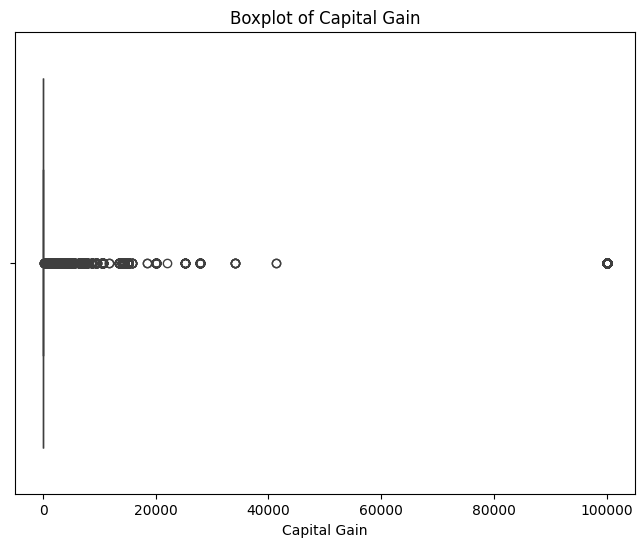

In [19]:

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['capital-gain'])
plt.title('Boxplot of Capital Gain')
plt.xlabel('Capital Gain')
plt.show()

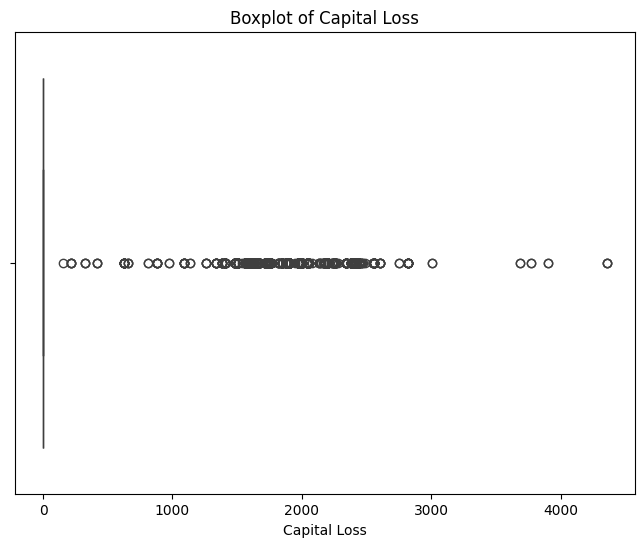

In [20]:

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['capital-loss'])
plt.title('Boxplot of Capital Loss')
plt.xlabel('Capital Loss')
plt.show()

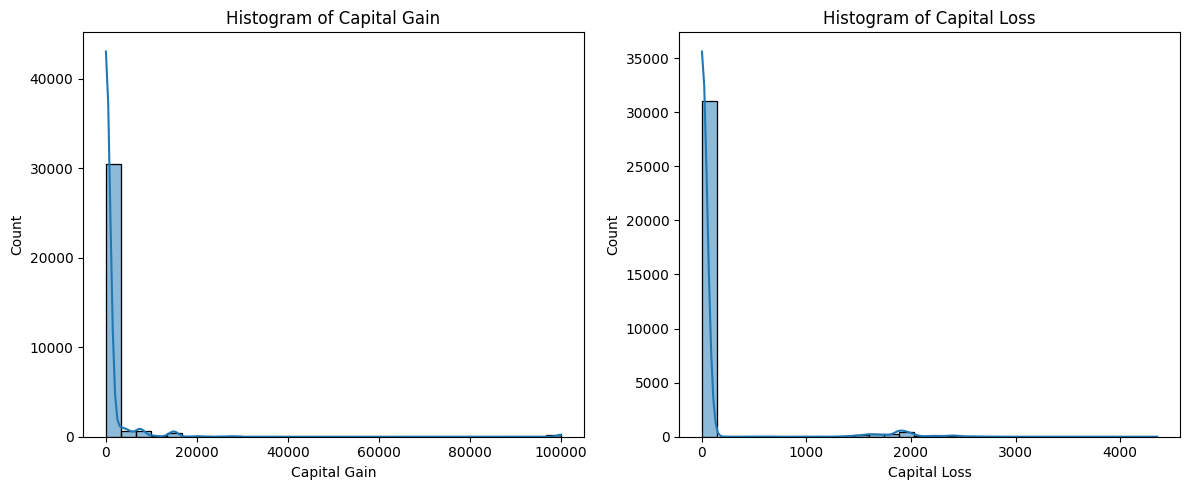

In [21]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['capital-gain'], bins=30, kde=True)
plt.title('Histogram of Capital Gain')
plt.xlabel('Capital Gain')
plt.subplot(1, 2, 2)
sns.histplot(df['capital-loss'], bins=30, kde=True)
plt.title('Histogram of Capital Loss')
plt.xlabel('Capital Loss')
plt.tight_layout()
plt.show()

<Axes: xlabel='capital-gain', ylabel='Count'>

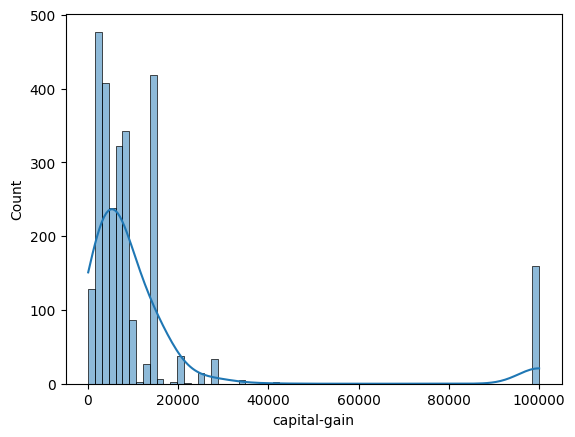

In [22]:

sns.histplot(df[df['capital-gain'] > 0]['capital-gain'], kde=True)

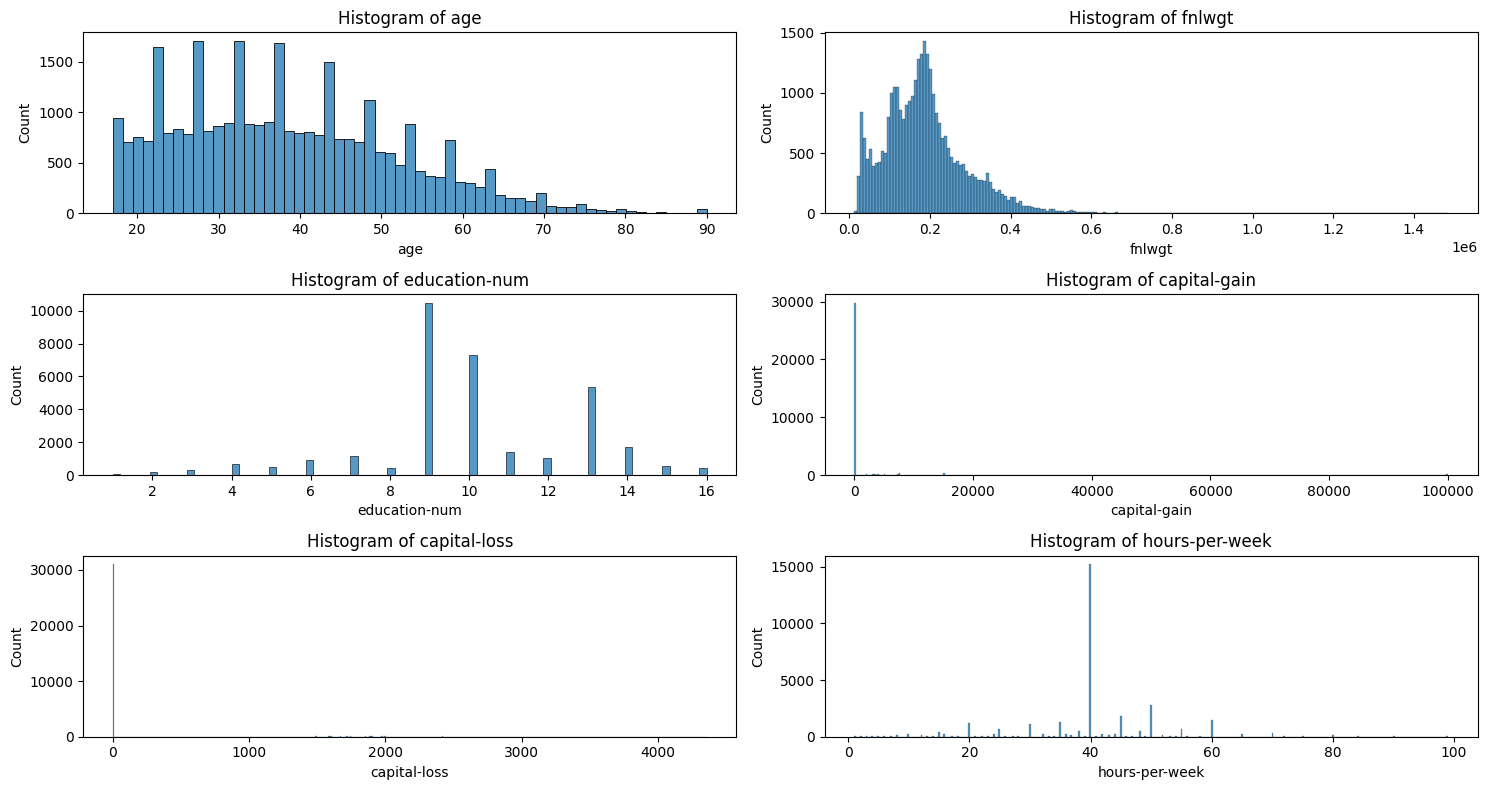

In [23]:

fig, axes = plt.subplots(3, 2, figsize=(15, 8)) 


for col, ax in zip(numerical_cols, axes.flatten()):
    sns.histplot(x=df[col], ax=ax)
    ax.set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

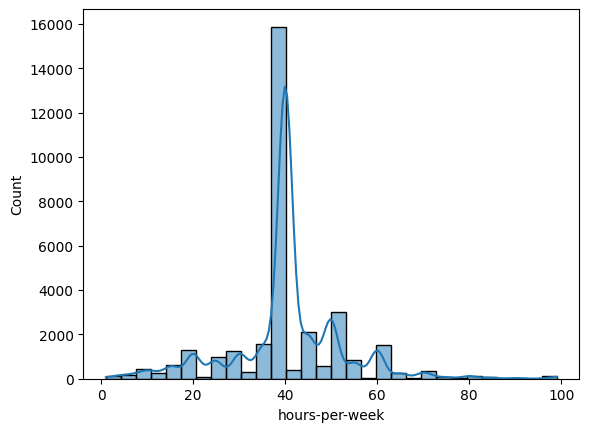

In [24]:
sns.histplot(df['hours-per-week'], bins=30, kde=True )

plt.show()

# Conclusion here: the Capital gain and loss are highly skewed, and most of the people have zero gain or loss.also, age and fnlwgt are also skewed. Meanwhile, the hours per week is more normally likly distributed, with a peak around 40 hours.

/var/folders/ry/vrk9vnj9163732zh7z8fc2wm0000gn/T/ipykernel_5783/1599397861.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/ry/vrk9vnj9163732zh7z8fc2wm0000gn/T/ipykernel_5783/1599397861.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/ry/vrk9vnj9163732zh7z8fc2wm0000gn/T/ipykernel_5783/1599397861.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/ry/vrk9vnj9163732zh7z8fc2wm0000gn/T/ipykernel_5783/1599397861.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and

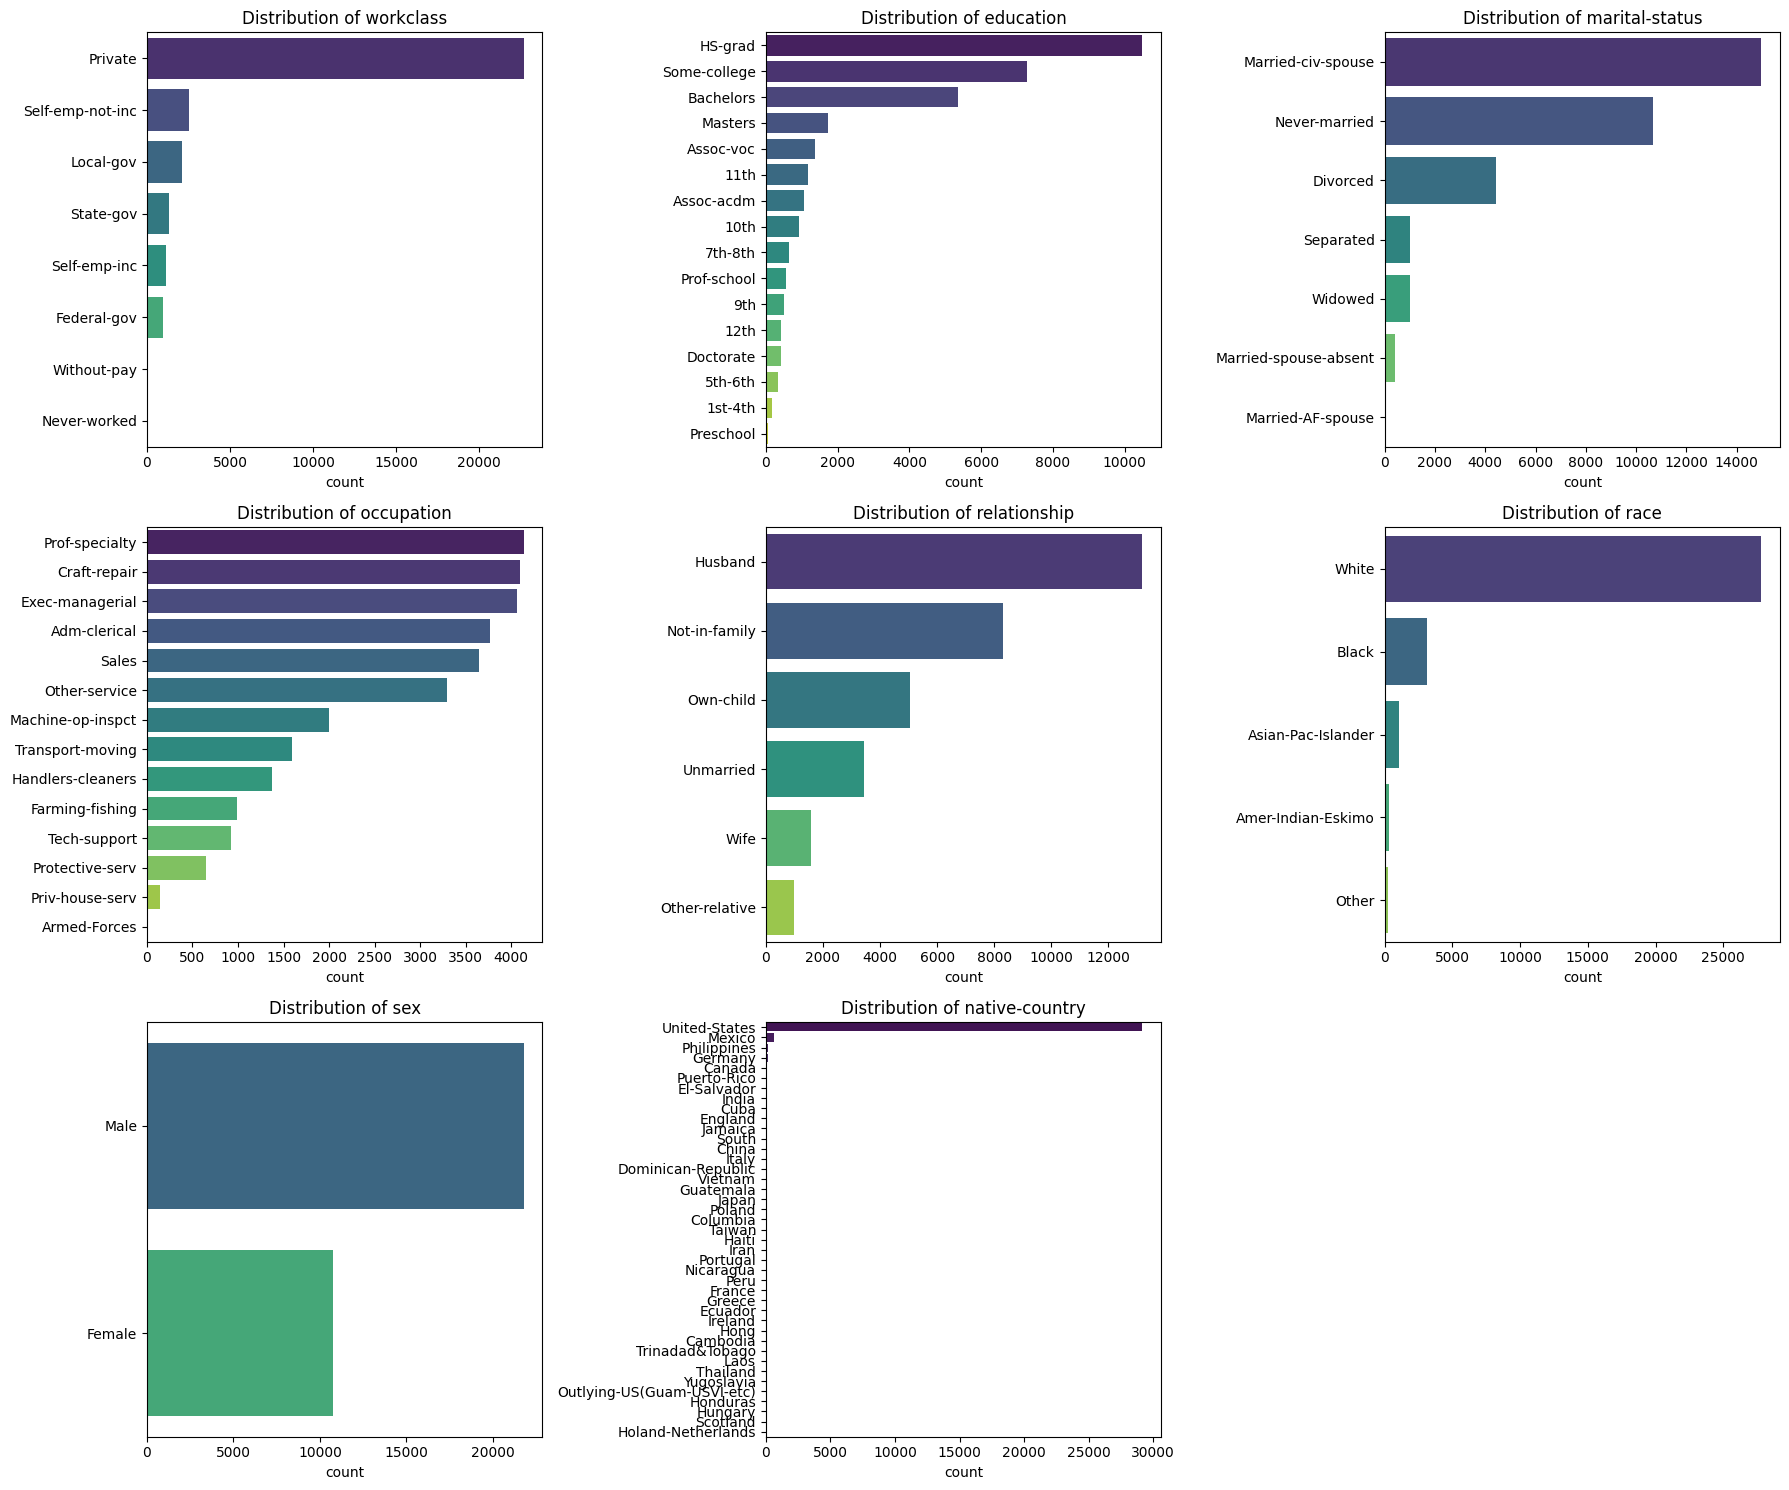

In [25]:

fig, axes = plt.subplots(3, 3, figsize=(18, 15)) 
axes_flat = axes.flatten()

for i, ax in enumerate(axes_flat):
    if i < len(categorical_cols):
        col = categorical_cols[i]
        
       
        sns.countplot(
            y=df[col], 
            ax=ax, 
            order=df[col].value_counts().index,
            palette="viridis" 
        )
        ax.set_title(f'Distribution of {col}')
        ax.set_ylabel('')
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

/var/folders/ry/vrk9vnj9163732zh7z8fc2wm0000gn/T/ipykernel_5783/892489532.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['income'] , palette="viridis")


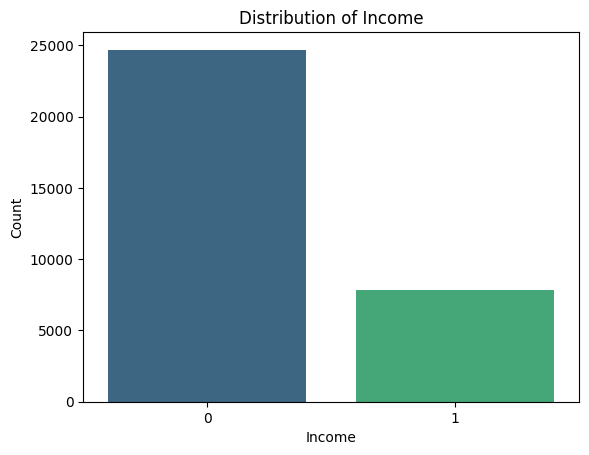

In [26]:

sns.countplot(x=df['income'] , palette="viridis")
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

# conclusion here: what i have observed from the categorical columns is that the maajority of the people from highly USA and imbalance in that eg. sex and race and target variable 


# Coleration Analysis

In [27]:
print(categorical_cols)
print(numerical_cols)
print(target_col)

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
['income']


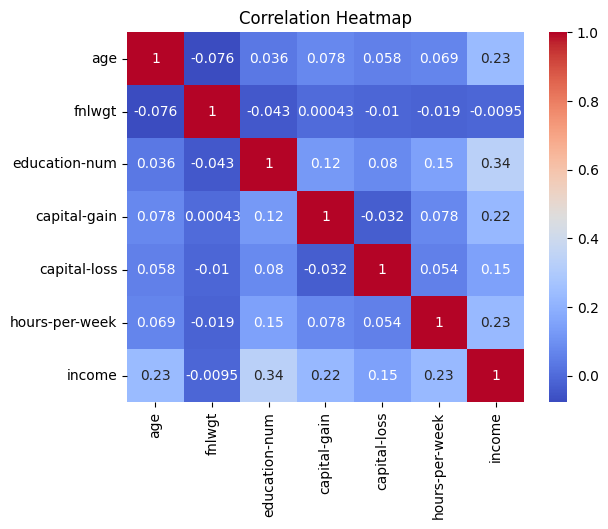

In [28]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## conclusion here : fnlwgt not correlate with any and not neccessary so remove them from dataframe is better and education and eduction are two columns so remove one from is import

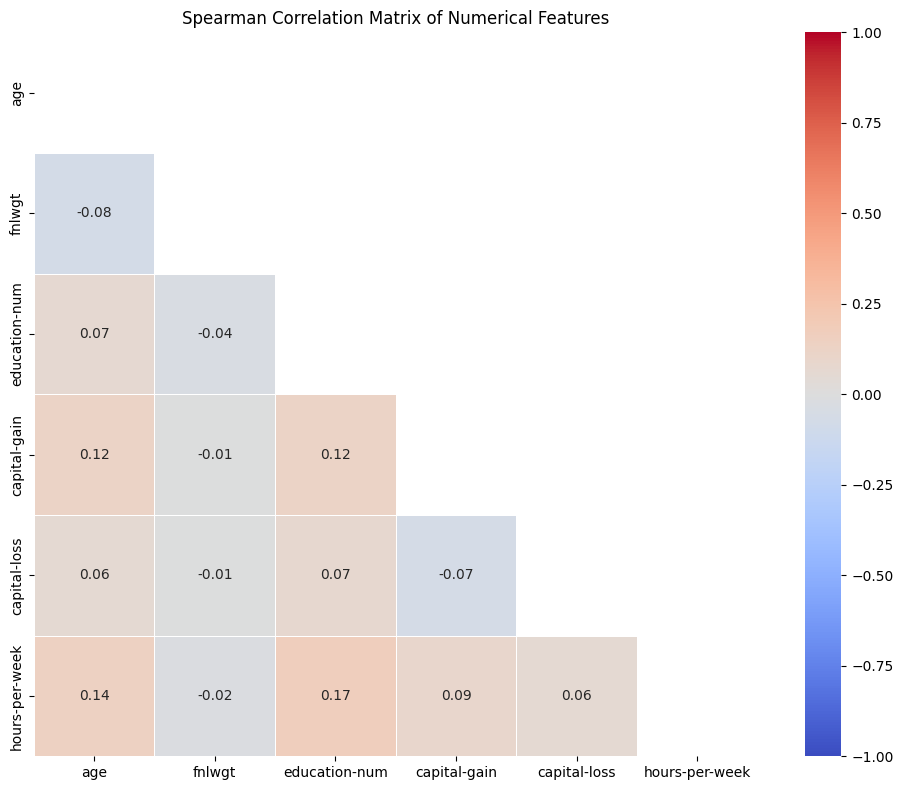

In [29]:
corr_matrix = df[numerical_cols].corr(method='spearman')

# 2. Create a mask to hide the upper triangle (for a clean, professional look)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,          # Shows the actual numbers
    fmt=".2f",           # Formats to 2 decimal places
    cmap="coolwarm",     # Red for positive, Blue for negative
    vmin=-1, vmax=1,     # Anchors the color scale
    square=True, 
    linewidths=.5
)
plt.title("Spearman Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

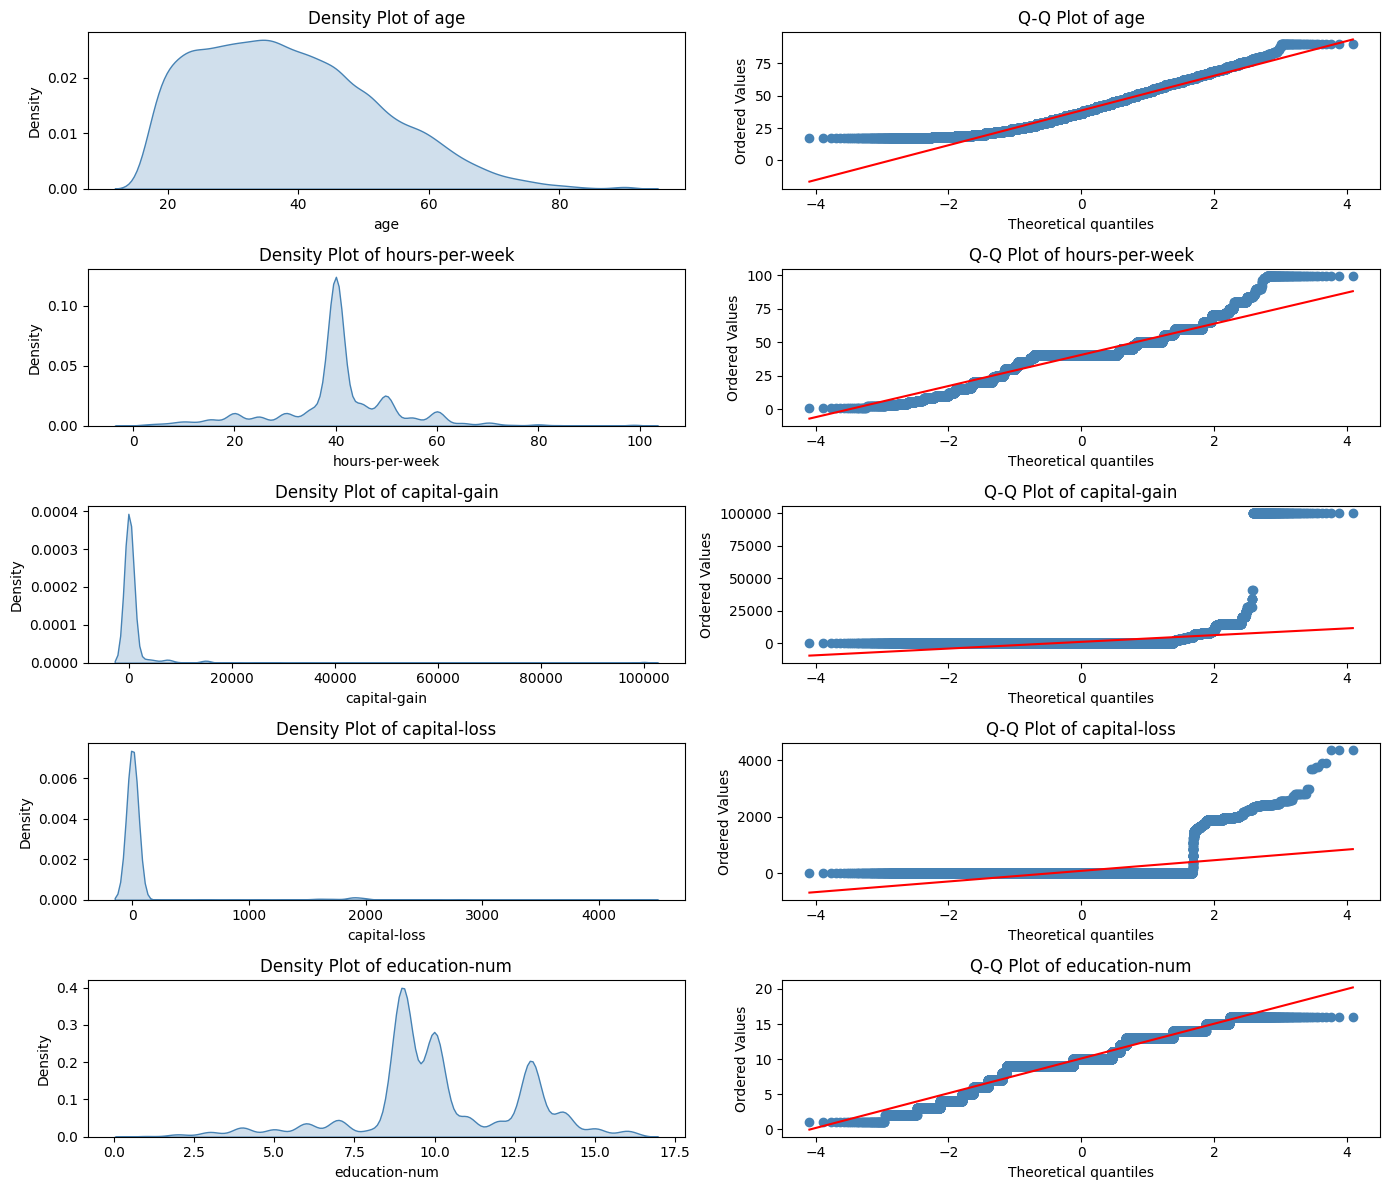

In [30]:


# Let's test three distinct types of distributions we found earlier
cols_to_check = ['age', 'hours-per-week', 'capital-gain', 'capital-loss', 'education-num']

fig, axes = plt.subplots(len(cols_to_check), 2, figsize=(14, 12))

for i, col in enumerate(cols_to_check):
    # 1. Density Plot (KDE - Kernel Density Estimate)
    sns.kdeplot(df[col], ax=axes[i, 0], fill=True, color='steelblue')
    axes[i, 0].set_title(f'Density Plot of {col}')
    
    # 2. Q-Q Plot
    # probplot compares the data distribution against a normal distribution ("norm")
    stats.probplot(df[col], dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'Q-Q Plot of {col}')
    axes[i, 1].get_lines()[0].set_markerfacecolor('steelblue') # Styling the dots
    axes[i, 1].get_lines()[0].set_markeredgecolor('steelblue')

plt.tight_layout()
plt.show()


# Data Preprocessing 

## Data cleaning 

### Remove columns 

In [31]:
df_copy.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='str')

In [32]:
df_copy = df_copy.drop(columns=['fnlwgt', 'education'], errors='ignore')

# 

### Correct the datatypes of columns

In [33]:
df_copy.columns.nunique()

13

In [34]:
df_copy.dtypes

age               int64
workclass           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income            int64
dtype: object

In [35]:
numerical_cols = df_copy.select_dtypes(include='number').columns.tolist()
categorical_cols = df_copy.select_dtypes(include=["object", "string", "category"]).columns.tolist()
df_copy[categorical_cols] = df_copy[categorical_cols].astype('category')
df_copy[numerical_cols] = df_copy[numerical_cols].astype('int64')

In [36]:
df_copy.dtypes

age                  int64
workclass         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
income               int64
dtype: object

In [37]:
df_copy.nunique()

age                73
workclass           8
education-num      16
marital-status      7
occupation         14
relationship        6
race                5
sex                 2
capital-gain      119
capital-loss       92
hours-per-week     94
native-country     41
income              2
dtype: int64

### Missing values

In [38]:
df_copy.isnull().sum().sort_values(ascending=False)

occupation        1843
workclass         1836
native-country     583
education-num        0
age                  0
marital-status       0
relationship         0
sex                  0
race                 0
capital-gain         0
capital-loss         0
hours-per-week       0
income               0
dtype: int64

In [39]:
missing_percent = (df.isnull().sum() * 100 / len(df)).sort_values(ascending=False).round(2)


print("\nMissing Values (%):")
print(missing_percent)



Missing Values (%):
occupation        5.66
workclass         5.64
native-country    1.79
fnlwgt            0.00
education         0.00
education-num     0.00
age               0.00
marital-status    0.00
relationship      0.00
sex               0.00
race              0.00
capital-gain      0.00
capital-loss      0.00
hours-per-week    0.00
income            0.00
dtype: float64


### conclusion here: missing values are the category and very low percentage if do KNN and random forest it cause bia in dataset and also not  Enough for low percentage i am going with simple imputer mode

In [40]:
df_copy["occupation"] = df_copy["occupation"].fillna(df_copy["occupation"].mode()[0])
df_copy["workclass"] = df_copy["workclass"].fillna(df_copy["workclass"].mode()[0])
df_copy['native-country'] = df_copy['native-country'].fillna(df_copy['native-country'].mode()[0])    
df_copy.isnull().sum().sort_values(ascending=False)

age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

## Removing the outliers

In [41]:
df_copy[numerical_cols]


,age,education-num,capital-gain,capital-loss,hours-per-week,income
0,39,13,2174,0,40,0
1,50,13,0,0,13,0
2,38,9,0,0,40,0
3,53,7,0,0,40,0
4,28,13,0,0,40,0
...,...,...,...,...,...,...
32556,27,12,0,0,38,0
32557,40,9,0,0,40,1
32558,58,9,0,0,40,0
32559,22,9,0,0,20,0


In [42]:
df_copy['Z_score'] = (df_copy['capital-gain'] - df_copy['capital-gain'].mean()) / df_copy['capital-gain'].std()


In [43]:
(df_copy['Z_score'].abs() > 3).sum()


np.int64(215)

In [44]:
(df_copy['Z_score'].abs() > 3).mean() * 100


np.float64(0.6602991308620743)

In [45]:
df_copy[df_copy['Z_score'].abs() > 3]


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,Z_score
106,17,Private,6,Never-married,Prof-specialty,Own-child,White,Female,34095,0,32,United-States,0,4.470690
704,46,Private,16,Divorced,Prof-specialty,Unmarried,White,Female,25236,0,65,United-States,1,3.271144
1246,54,Self-emp-inc,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999,0,60,United-States,1,13.394372
1368,52,Private,9,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male,99999,0,40,Japan,1,13.394372
1482,53,Self-emp-inc,9,Married-civ-spouse,Sales,Husband,White,Male,99999,0,40,United-States,1,13.394372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31972,43,Self-emp-inc,15,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,40,United-States,1,13.394372
32090,66,Private,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,55,United-States,1,13.394372
32238,47,Private,15,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,40,United-States,1,13.394372
32370,53,Self-emp-not-inc,15,Never-married,Prof-specialty,Not-in-family,Asian-Pac-Islander,Male,27828,0,40,Philippines,1,3.622111


In [46]:
df_copy.drop(columns=['Z_score'], inplace=True)


In [47]:
df_copy[numerical_cols]

,age,education-num,capital-gain,capital-loss,hours-per-week,income
0,39,13,2174,0,40,0
1,50,13,0,0,13,0
2,38,9,0,0,40,0
3,53,7,0,0,40,0
4,28,13,0,0,40,0
...,...,...,...,...,...,...
32556,27,12,0,0,38,0
32557,40,9,0,0,40,1
32558,58,9,0,0,40,0
32559,22,9,0,0,20,0


In [48]:
df_copy["z_score"] = (df_copy["capital-loss"] - df_copy["capital-loss"].mean()) / df_copy["capital-loss"].std()



In [49]:
outlier_mask = df_copy['z_score'].abs() > 3

print("TOTAL OUTLIERS:", outlier_mask.sum())
print("PERCENTAGE OF OUTLIERS:", outlier_mask.mean() * 100)


TOTAL OUTLIERS: 1470
PERCENTAGE OF OUTLIERS: 4.514603359847671


In [50]:
df_copy['capital-loss'].value_counts().head()

capital-loss
0       31042
1902      202
1977      168
1887      159
1485       51
Name: count, dtype: int64

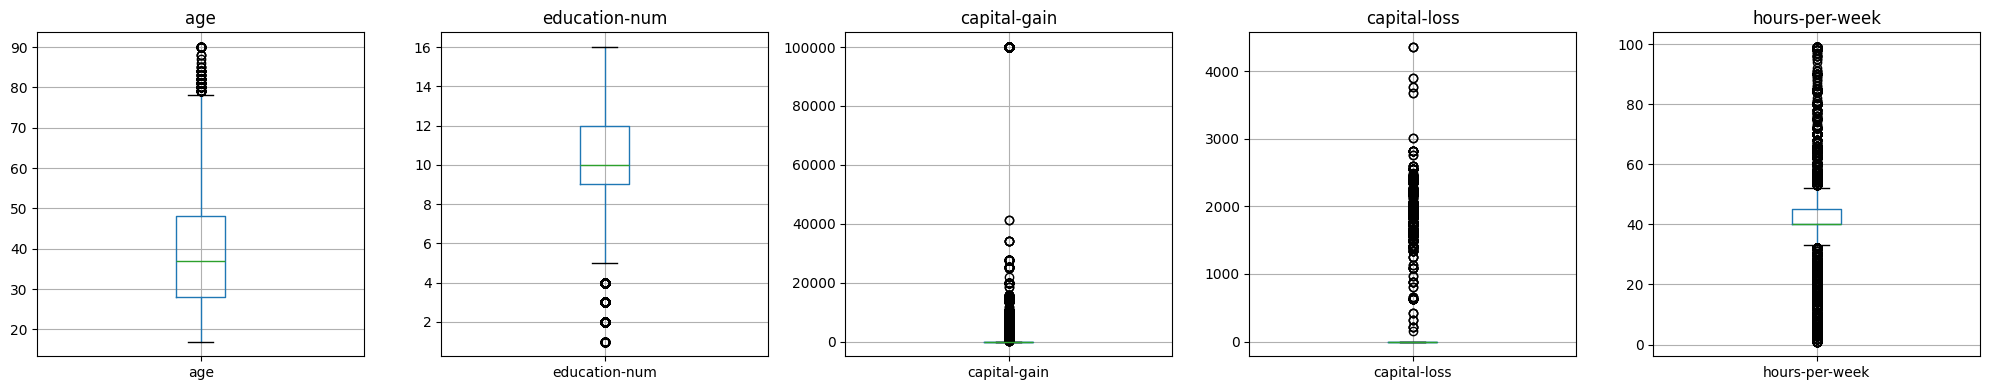

In [51]:

numerical_cols = ['age', 'education-num', 'capital-gain', 
                  'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(20, 4))

for i, col in enumerate(numerical_cols):
    df_copy.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [52]:
print(df_copy['hours-per-week'].describe())
print("\nOver 80 hours:", (df_copy['hours-per-week'] == 99).sum())
print("Under 10 hours:", (df_copy['hours-per-week'] < 10).sum())

count    32561.000000
mean        40.437456
std         12.347429
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64

Over 80 hours: 85
Under 10 hours: 458


In [53]:
print((df_copy['hours-per-week'] == 99).sum())
df_copy[df_copy['hours-per-week'] == 99]['occupation'].value_counts()

85


occupation
Prof-specialty       23
Exec-managerial      12
Farming-fishing      12
Other-service        11
Transport-moving     10
Craft-repair          7
Protective-serv       3
Sales                 3
Priv-house-serv       2
Tech-support          2
Adm-clerical          0
Armed-Forces          0
Handlers-cleaners     0
Machine-op-inspct     0
Name: count, dtype: int64

In [54]:
df_copy = df_copy.drop(columns=['z_score'], errors='ignore')

In [55]:
df_copy.columns

Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country', 'income'],
      dtype='str')

## conculsion here: no outliers find basically data points are real and gives  real information so no need to delete it

In [56]:
df_copy.drop_duplicates(inplace=True)

# Pipeline for modeling

### Data spiliting 

In [57]:
X = df_copy.drop(columns=['income'])
y = df_copy['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 , stratify=y)
X_test_audit = X_test.copy()
print ( X_test_audit.shape )
print(X_test.shape)

(5794, 12)
(5794, 12)


### data preprocessing  using pipeline

In [58]:
print(categorical_cols)
print(numerical_cols)

['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [59]:
numeric_features = Pipeline(steps=[
    ('scaler', MinMaxScaler()   )
])
categorical_features = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_features, numerical_cols),
        ('cat', categorical_features, categorical_cols)
    ]
)


### Modeling 

In [60]:
pipeline =Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier( n_estimators=100, random_state=42, class_weight='balanced'))  # Placeholder for the actual model]
])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

### Evaluation 

In [61]:
# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
precision = precision_score(y_test, y_pred)
print("Precision Score:", precision)
recall = recall_score(y_test, y_pred)
print("Recall Score:", recall)
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)  

Accuracy: 0.8331032102174664
Precision Score: 0.6816421378776143
Recall Score: 0.6128133704735376
F1 Score: 0.6453978731206454


ROC AUC Score: 0.8812568631185755


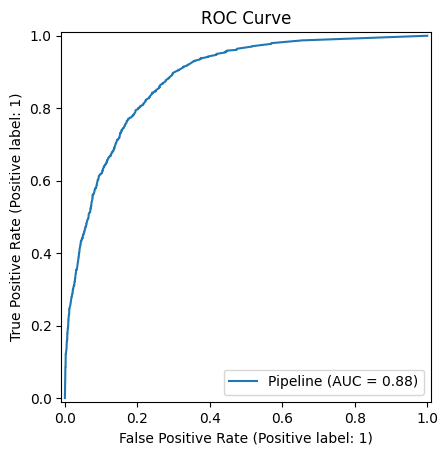

In [62]:
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc}")
RocCurveDisplay.from_estimator(
    pipeline, X_test, y_test)
plt.title('ROC Curve')
plt.savefig('roc_curve.png', dpi=150)
plt.show()

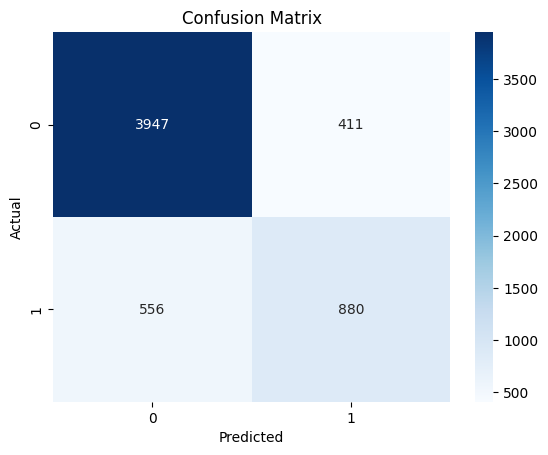

In [63]:
# make a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

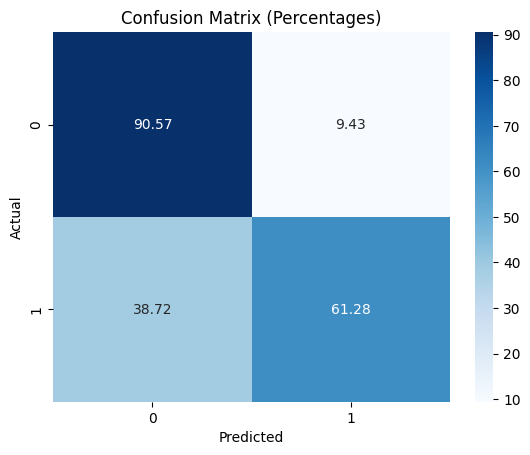

In [64]:

conf_matrix_percent = confusion_matrix(y_test, y_pred, normalize='true') * 100
sns.heatmap(conf_matrix_percent, annot=True, fmt='.2f', cmap='Blues')
plt.title('Confusion Matrix (Percentages)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [65]:
#make a classification report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89      4358
           1       0.68      0.61      0.65      1436

    accuracy                           0.83      5794
   macro avg       0.78      0.76      0.77      5794
weighted avg       0.83      0.83      0.83      5794



# Fairness audit code split by Sex column 

In [66]:
X_test_audit.nunique()

age               71
workclass          8
education-num     16
marital-status     7
occupation        14
relationship       6
race               5
sex                2
capital-gain      88
capital-loss      61
hours-per-week    77
native-country    39
dtype: int64

In [67]:
df_copy['income'].value_counts()

income
0    21790
1     7180
Name: count, dtype: int64

In [68]:
y_train.value_counts()

income
0    17432
1     5744
Name: count, dtype: int64

In [69]:
y_test.value_counts()

income
0    4358
1    1436
Name: count, dtype: int64

/var/folders/ry/vrk9vnj9163732zh7z8fc2wm0000gn/T/ipykernel_5783/2830572116.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_copy['sex'], palette="viridis")


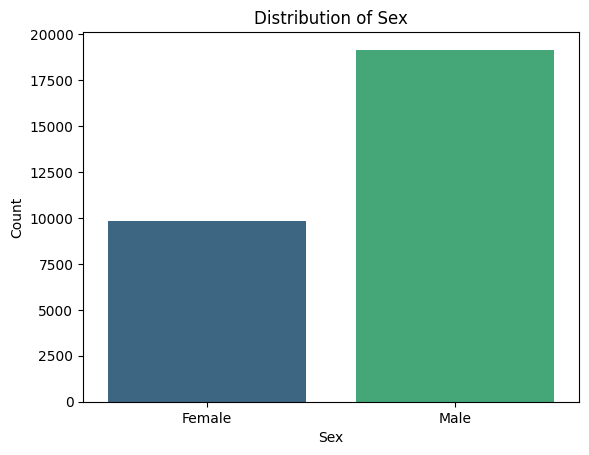

In [ ]:

sns.countplot(x=df_copy['sex'], palette="viridis")
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

In [72]:
audit_df = X_test_audit.copy()
audit_df['True_Income'] = y_test
audit_df['Predicted_Income'] = y_pred


male_df = audit_df[audit_df['sex'] == 'Male']
female_df = audit_df[audit_df['sex'] == 'Female']
print("="*50)
print("CLASSIFICATION REPORT: MALE GROUP")
print("="*50)
print(classification_report(male_df['True_Income'], male_df['Predicted_Income']))

print("\n" + "="*50)
print("CLASSIFICATION REPORT: FEMALE GROUP")
print("="*50)
print(classification_report(female_df['True_Income'], female_df['Predicted_Income']))



CLASSIFICATION REPORT: MALE GROUP
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      2621
           1       0.68      0.64      0.66      1193

    accuracy                           0.79      3814
   macro avg       0.76      0.75      0.75      3814
weighted avg       0.79      0.79      0.79      3814


CLASSIFICATION REPORT: FEMALE GROUP
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1737
           1       0.69      0.49      0.58       243

    accuracy                           0.91      1980
   macro avg       0.81      0.73      0.76      1980
weighted avg       0.90      0.91      0.90      1980



# Two separate confusion matrices side by side for Sex (male and female)

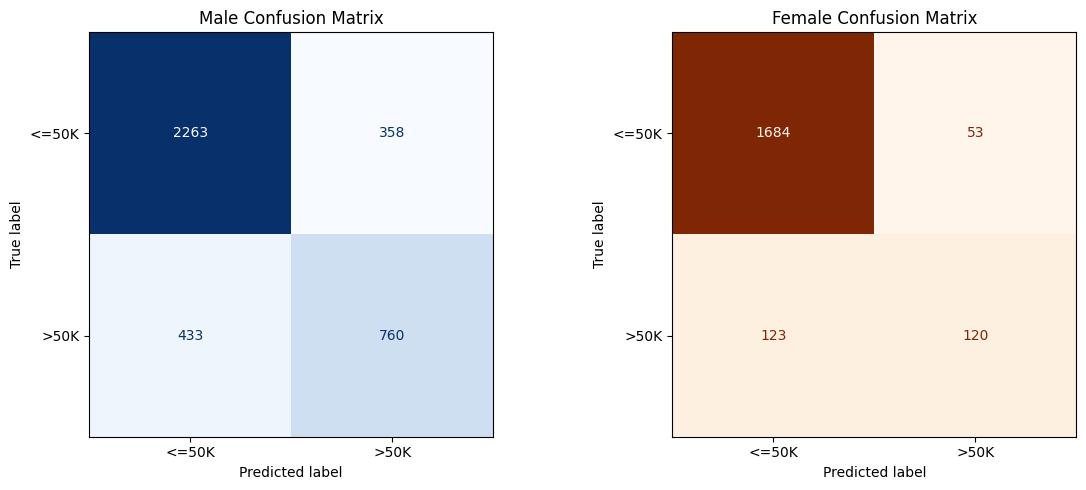

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

male_cm = confusion_matrix(male_df['True_Income'], male_df['Predicted_Income'])
ConfusionMatrixDisplay(male_cm, display_labels=['<=50K', '>50K']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Male Confusion Matrix')

female_cm = confusion_matrix(female_df['True_Income'], female_df['Predicted_Income'])
ConfusionMatrixDisplay(female_cm, display_labels=['<=50K', '>50K']).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('Female Confusion Matrix')

plt.tight_layout()
plt.show()


In [75]:
df_copy['sex'].value_counts().sum()

np.int64(28970)

# FAIRNESS CRITERIA

In [81]:

male_TN, male_FP, male_FN, male_TP = male_cm.ravel()
female_TN, female_FP, female_FN, female_TP = female_cm.ravel()

print("\n--- MATRIX COUNTS FOR FAIRNESS CRITERIA ---")
print(f"MALE Matrix:   TP={male_TP}, FP={male_FP}, FN={male_FN}, TN={male_TN}")
print(f"FEMALE Matrix: TP={female_TP}, FP={female_FP}, FN={female_FN}, TN={female_TN}")


--- MATRIX COUNTS FOR FAIRNESS CRITERIA ---
MALE Matrix:   TP=760, FP=358, FN=433, TN=2263
FEMALE Matrix: TP=120, FP=53, FN=123, TN=1684


# EQUAL ACCURACY

In [90]:
male_accuracy   = (male_TP + male_TN) / (male_TP + male_TN + male_FP + male_FN)
female_accuracy = (female_TP + female_TN) / (female_TP + female_TN + female_FP + female_FN)
diff_accuracy   = abs(male_accuracy - female_accuracy)

print(f"\n1. EQUAL ACCURACY")
print(f"   Male Accuracy   : {male_accuracy * 100:.2f}%")
print(f"   Female Accuracy : {female_accuracy * 100:.2f}%")
print(f"   Difference      : {diff_accuracy * 100:.2f}%")
if diff_accuracy > 0.10:
    print("   BIAS DETECTED ")
else:
    print("   No significant bias ")


1. EQUAL ACCURACY
   Male Accuracy   : 79.26%
   Female Accuracy : 91.11%
   Difference      : 11.85%
   BIAS DETECTED 


# DEMOGRAPHIC PARITY

In [89]:
male_positive_rate   = (male_TP + male_FP) / (male_TP + male_TN + male_FP + male_FN)
female_positive_rate = (female_TP + female_FP) / (female_TP + female_TN + female_FP + female_FN)


disparate_impact_ratio = female_positive_rate / (male_positive_rate)

print(f"\n2. DEMOGRAPHIC PARITY")
print(f"   Male predicted rich rate   : {male_positive_rate * 100:.2f}%")
print(f"   Female predicted rich rate : {female_positive_rate * 100:.2f}%")
print(f"   Disparate Impact Ratio     : {disparate_impact_ratio * 100:.1f}%)")
if disparate_impact_ratio < 0.80:
    print("   BIAS DETECTED (Fails Four-Fifths Rule) ")
else:
    print("   No significant bias (Passes Four-Fifths Rule) ")



2. DEMOGRAPHIC PARITY
   Male predicted rich rate   : 29.31%
   Female predicted rich rate : 8.74%
   Disparate Impact Ratio     : 29.8%)
   BIAS DETECTED (Fails Four-Fifths Rule) 


# EQUAL OPPORTUNITY

In [87]:
male_recall   = male_TP / (male_TP + male_FN)
female_recall = female_TP / (female_TP + female_FN)
diff_recall   = abs(male_recall - female_recall)

print(f"\n3. EQUAL OPPORTUNITY")
print(f"   Male Recall (rich)   : {male_recall * 100:.2f}%")
print(f"   Female Recall (rich) : {female_recall * 100:.2f}%")
print(f"   Difference           : {diff_recall * 100:.2f}%")
if diff_recall > 0.05:
    print("   BIAS DETECTED ")
else:
    print("   No significant bias ")


3. EQUAL OPPORTUNITY
   Male Recall (rich)   : 63.70%
   Female Recall (rich) : 49.38%
   Difference           : 14.32%
   BIAS DETECTED 


# COMAPRARION OF THREE FAIRNESS CERTIERA

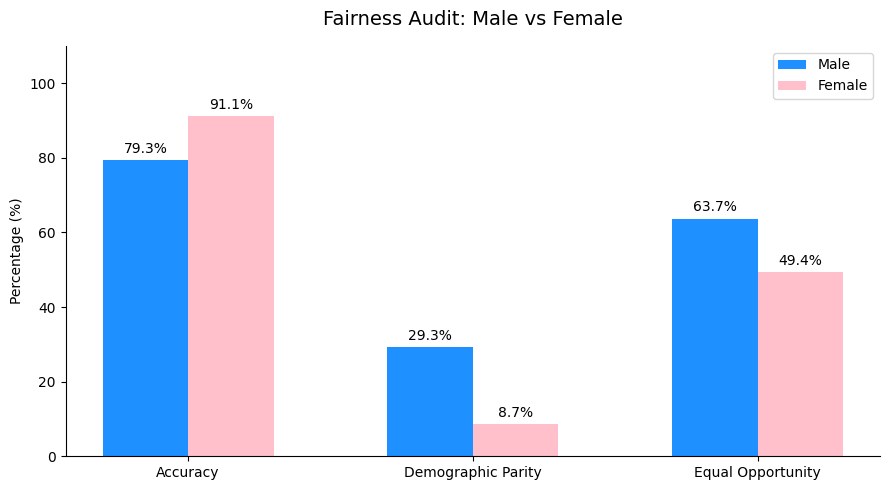

In [88]:
labels = ['Accuracy', 'Demographic Parity', 'Equal Opportunity']
male_scores = [79.3, 29.3, 63.7]
female_scores = [91.1, 8.7, 49.4]

x = np.arange(len(labels))
width = 0.30

fig, ax = plt.subplots(figsize=(9, 5))

# Simple bars
rects1 = ax.bar(x - width/2, male_scores, width, label='Male', color='dodgerblue')
rects2 = ax.bar(x + width/2, female_scores, width, label='Female', color='pink')

# Clean labels
ax.set_title('Fairness Audit: Male vs Female', fontsize=14, pad=15)
ax.set_ylabel('Percentage (%)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 110)
ax.legend()

# Add simple percentage labels on top
ax.bar_label(rects1, padding=3, fmt='%.1f%%')
ax.bar_label(rects2, padding=3, fmt='%.1f%%')

# Remove top and right borders for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# The Three Limitations in the dataset

Limitation 1  Equal Accuracy is Misleading:
Equal Accuracy showed female group 
performing better (91.1% vs 79.3%)

BUT this is misleading because:
- Female group has severe class imbalance
- Only 12% of women in dataset are rich
- Model predicts poor for almost everyone
- Gets high accuracy doing almost nothing
- This is called the Accuracy Paradox

Limitation:
Equal Accuracy fails completely
on imbalanced datasets
Cannot be used alone as fairness metric

Limitation 2  Demographic Parity Ignores Reality:
Demographic Parity says:
Model should predict rich at same rate
for men and women (29.3% vs 8.7%)

BUT this ignores:
- In real 1990s census data
- Women genuinely earned less
- Due to historical discrimination
- Fewer women in high paying jobs

Limitation:
Demographic Parity cannot distinguish
between model bias and real world
historical inequality

Forcing equal prediction rates
might actually mean predicting
rich for unqualified people
just to satisfy the metric

This is called Fairness Through
Unawareness problem



Limitation 3  Equal Opportunity Cannot Satisfy Everything:
Equal Opportunity focuses only on
correctly identifying rich people

BUT:
- Improving recall for women
  means lowering threshold
- Lower threshold = more false positives
- More false positives = less precision
- You fix one group, break another

This is called the
Fairness Impossibility Theorem

You mathematically CANNOT satisfy
all three criteria simultaneously
when base rates differ between groups

Chouldechova (2017) proved that
demographic parity and equal opportunity
cannot both be satisfied at same time
unless the groups have equal base rates